Antal utan m-komponent i träningsdatan: 17903
Antal med m-komponent i träningsdatan: 2553
Total parameters: 320,194
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   0 | train: 0.4898 | val: 0.2329 | acc: 96.68% | AUC: 0.953  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   1 | train: 0.1975 | val: 0.0777 | acc: 98.54% | AUC: 0.993  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   2 | train: 0.1401 | val: 0.0874 | acc: 97.51% | AUC: 0.996  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   3 | train: 0.1178 | val: 0.0538 | acc: 98.75% | AUC: 0.996  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   4 | train: 0.1102 | val: 0.0629 | acc: 98.21% | AUC: 0.997  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   5 | train: 0.1031 | val: 0.0639 | acc: 98.45% | AUC: 0.9

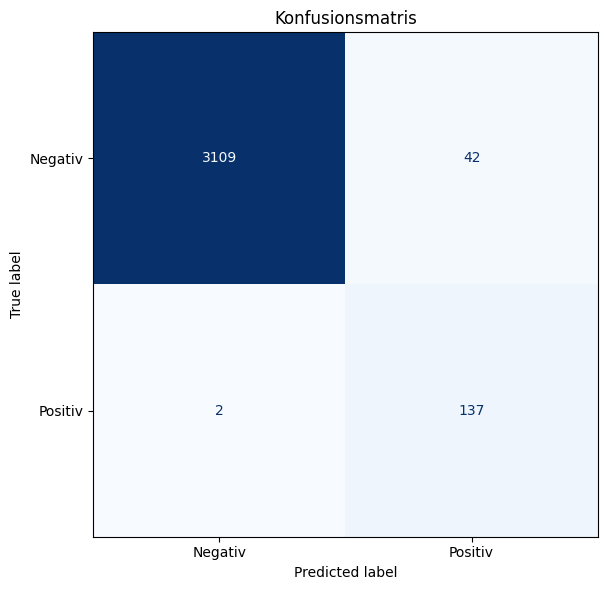

AUC: 0.9980593119918537
Accuracy:  98.66%
FN-rate:   1.44%  (farliga missade fall)
FP-rate:   1.33%  (onödiga larm)
Sensitivitet:   98.56%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   98.67%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9981


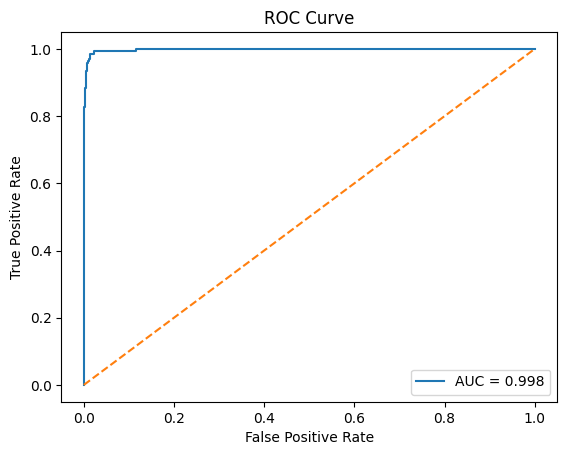

In [2]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders

con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE observation_nr = 1
                 """).df()
con.close()



train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")


CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)
result = CNN.predict(val_rows)
_ = CNN.evaluate(result)

In [ ]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders

con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 """).df()
con.close()



train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']


train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")


CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
result = CNN.predict(val_rows)
_ = CNN.evaluate(result)

Antal utan m-komponent i träningsdatan: 18156
Antal med m-komponent i träningsdatan: 2714
Total parameters: 320,194
              precision    recall  f1-score   support

     Negativ       0.86      0.99      0.92      4637
     Positiv       0.97      0.60      0.74      1898

    accuracy                           0.88      6535
   macro avg       0.91      0.80      0.83      6535
weighted avg       0.89      0.88      0.87      6535

[[4601   36]
 [ 762 1136]]


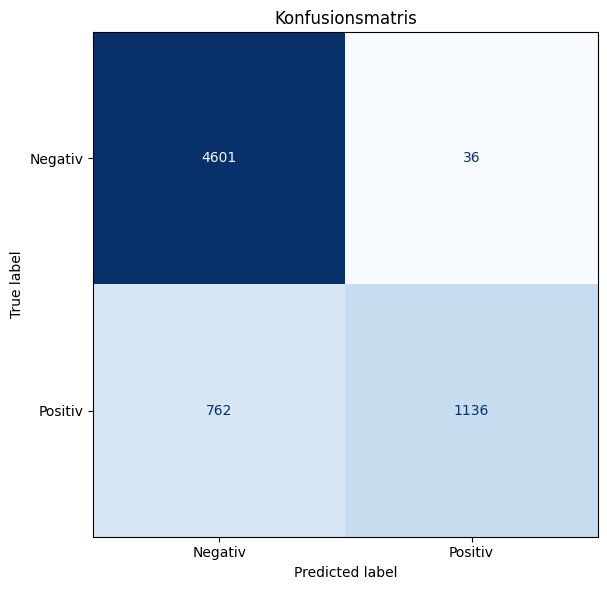

AUC: 0.811777967705129
Accuracy:  87.79%
FN-rate:   40.15%  (farliga missade fall)
FP-rate:   0.78%  (onödiga larm)
Sensitivitet:   59.85%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   99.22%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.8118


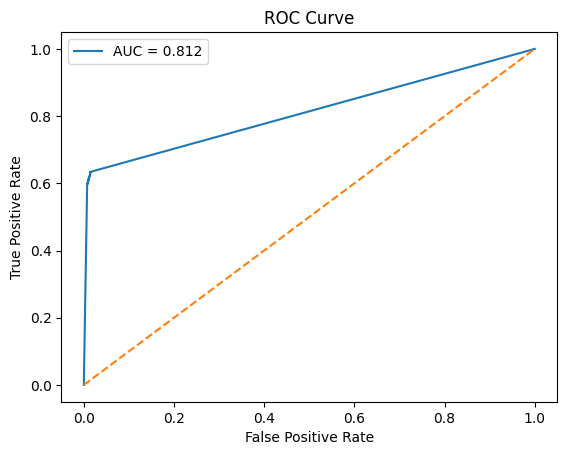

  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   0 | train: 0.3445 | val: 0.5135 | acc: 89.66% | AUC: 0.904  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   1 | train: 0.1420 | val: 0.1920 | acc: 94.93% | AUC: 0.967  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   2 | train: 0.1141 | val: 0.1536 | acc: 96.11% | AUC: 0.979  | LR: 0.001
Epoch   3 | train: 0.1025 | val: 0.2081 | acc: 96.22% | AUC: 0.976  | LR: 0.001
Epoch   4 | train: 0.0922 | val: 0.1835 | acc: 96.78% | AUC: 0.978  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   5 | train: 0.0824 | val: 0.1534 | acc: 96.68% | AUC: 0.981  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   6 | train: 0.0785 | val: 0.1655 | acc: 96.60% | AUC: 0.981  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   7 | train: 0

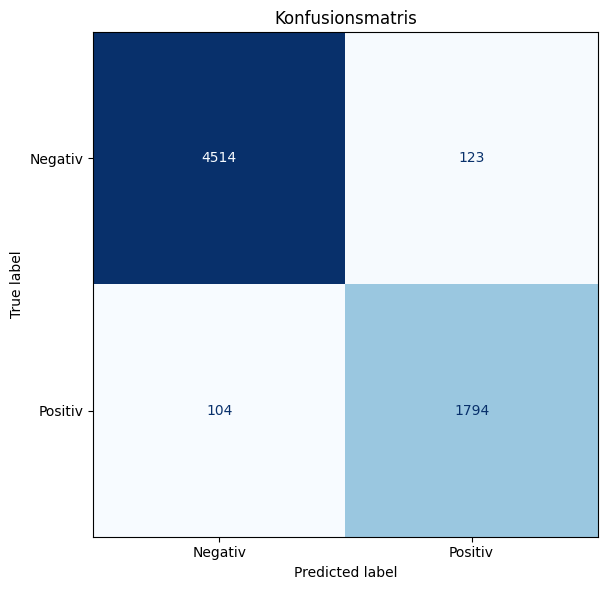

AUC: 0.9839205110858665
Accuracy:  96.53%
FN-rate:   5.48%  (farliga missade fall)
FP-rate:   2.65%  (onödiga larm)
Sensitivitet:   94.52%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   97.35%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9839


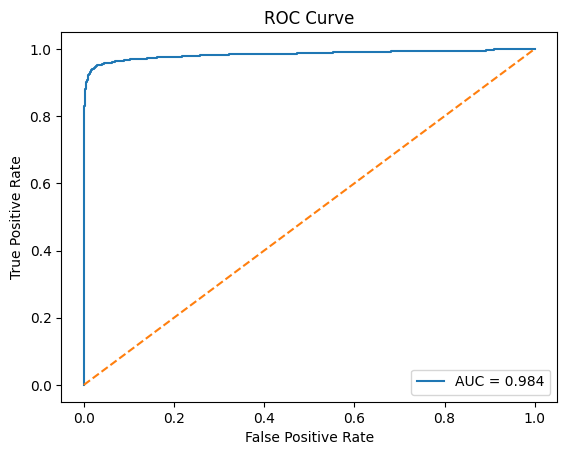

In [9]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders

con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 """).df()
con.close()



train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 1].sample(frac=0.58).index
train_rows = train_rows.drop(drop_indices)

drop_indices = train_rows.sample(frac=0.8).index
train_rows = train_rows.drop(drop_indices)


train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")


CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
result = CNN.predict(val_rows)
_ = CNN.evaluate(result)

CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)
result = CNN.predict(val_rows)
_ = CNN.evaluate(result)

Antal utan m-komponent i träningsdatan: 17890
Antal med m-komponent i träningsdatan: 765
              precision    recall  f1-score   support

     Negativ       1.00      0.98      0.99      3151
     Positiv       0.69      0.97      0.81       139

    accuracy                           0.98      3290
   macro avg       0.84      0.98      0.90      3290
weighted avg       0.99      0.98      0.98      3290

[[3090   61]
 [   4  135]]


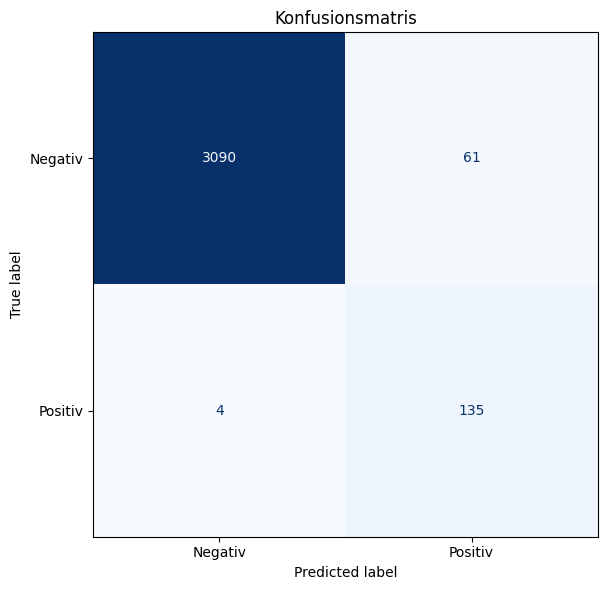

AUC: 0.9953857288653368
Accuracy:  98.02%
FN-rate:   2.88%  (farliga missade fall)
FP-rate:   1.94%  (onödiga larm)
Sensitivitet:   97.12%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   98.06%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9954


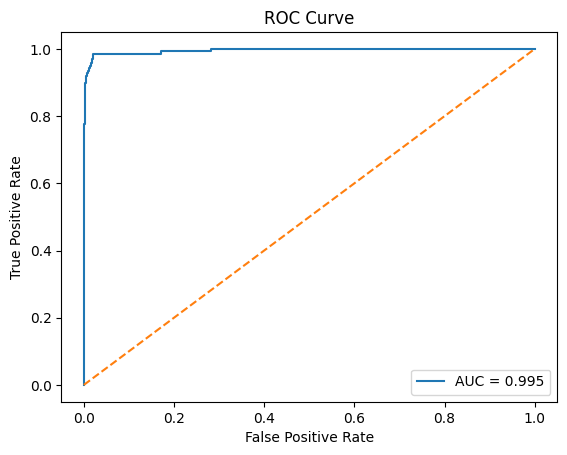

In [11]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders

con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE observation_nr = 1
                 """).df()
con.close()



train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows.sample(frac=0.7).index
train_rows = train_rows.drop(drop_indices)


train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")


result = CNN.predict(val_rows)
_ = CNN.evaluate(result)

In [ ]:
con = duckdb.connect('../capillary.db')
negatives = con.execute(""" 
                 SELECT id FROM protein_data WHERE array_contains(analysis,'0085') AND interpretation ILIKE '%ingen%m%komponent%påvisas%immunfixation%utförd%';
                 """).fetchnumpy()['id']
positives = con.execute(""" 
                 SELECT id FROM protein_data WHERE array_contains(analysis,'0085') AND interpretation ILIKE '%nyupptäckt%m%komponent%';
                 """).fetchnumpy()['id']

df = con.execute(""" 
                 SELECT id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()
negatives = set(negatives)
positives = set(positives)

df = df[df['id'].isin(negatives | positives)]

df['label'] = df['id'].apply(
    lambda x: 1 if x in positives else 0
)

test_rows = test_rows[test_rows['label'].isin([0,1])]

result = CNN.predict(df)
_ = CNN.evaluate(result)

              precision    recall  f1-score   support

     Negativ       0.94      0.77      0.85      7362
     Positiv       0.65      0.90      0.76      3474

    accuracy                           0.81     10836
   macro avg       0.80      0.84      0.80     10836
weighted avg       0.85      0.81      0.82     10836

[[5691 1671]
 [ 337 3137]]
Accuracy:  81.47%
FN-rate:   9.70%  (farliga missade fall)
FP-rate:   22.70%  (onödiga larm)
Sensitivitet:   90.30%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   50.00%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)


(array([0.9818671 , 0.38031605, 0.9994518 , ..., 0.25963417, 0.9819756 ,
        0.15651882], shape=(10836,), dtype=float32),
 array([1, 0, 1, ..., 0, 1, 0], shape=(10836,)),
 20        1
 35        0
 67        1
 68        1
 87        1
          ..
 172434    0
 172445    1
 172452    0
 172460    1
 172509    0
 Name: proportion_gamma_region, Length: 10836, dtype: int64,
 array([155130, 170004, 160177, ...,  88747, 152636, 137883],
       shape=(10836,)))